# 08 — Production-Side Mirror: Top Producers + Quantity/Value Timelines

This notebook builds the GROW (production-side) parallel to the TRADE deck's
import charts. Where TRADE showed *import* quantity vs *import* value for a
vulnerable importer, here we show *production* quantity (QCL) vs *production*
value (QV) for the same countries — the supply-side mirror image.

Contents:
1. Top wheat producers (bar)
2. Top rice producers (bar)
3. Indonesia — wheat production: quantity vs value, stacked panels (2015–2024)
4. China — rice production: quantity vs value, stacked panels (2015–2024)

Reading tip: on the *import* side, quantity and value diverging = vulnerability
(paying more for less). On the *production* side, quantity and value diverging
tells a different story — e.g. value rising faster than volume = price/mix gains,
value falling while volume holds = deteriorating terms for producers.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import pandas as pd
import matplotlib.pyplot as plt

from src.load import load_dataset
from src.clean import standardize_columns, split_aggregates, resolve_china, flag_item_aggregates
from src.viz import save

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 1. Load QCL (production quantity) and QV (production value)

In [2]:
qcl = standardize_columns(load_dataset("QCL"))
qv = standardize_columns(load_dataset("QV"))

prod = qcl[qcl["element"] == "Production"].copy()
# QV value element: current US$ is closest to how the TRADE import-value panel is scaled.
QV_ELEMENT = "Gross Production Value (current thousand US$)"
val = qv[qv["element"] == QV_ELEMENT].copy()
print("value element rows:", len(val), "| present:", QV_ELEMENT in qv["element"].unique())

[cache] QCL_long.parquet


[cache] QV_long.parquet


value element rows: 488916 | present: True


## 2. Top WHEAT producers (latest year)

In [3]:
def top_producers(df, item, year, n=10):
    countries, _ = split_aggregates(df[df["year"] == year])
    countries = resolve_china(countries)
    countries = countries[~flag_item_aggregates(countries)]
    sub = countries[countries["item"] == item]
    out = (sub.groupby("area")["value"].sum().sort_values(ascending=False)
           .head(n).rename("production_t").reset_index())
    out["production_Mt"] = (out["production_t"] / 1e6).round(1)
    return out

year = int(prod["year"].max())
wheat_top = top_producers(prod, "Wheat", year, 10)
print(f"Top 10 wheat producers ({year}):")
print(wheat_top[["area", "production_Mt"]].to_string(index=False))

Top 10 wheat producers (2024):
                    area  production_Mt
         China, mainland          140.1
                   India          113.3
      Russian Federation           82.6
United States of America           53.7
                  Canada           35.9
               Australia           34.1
                Pakistan           31.8
                  France           26.6
                 Ukraine           22.4
                TÃ¼rkiye           20.8


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/top10_wheat_producers.png


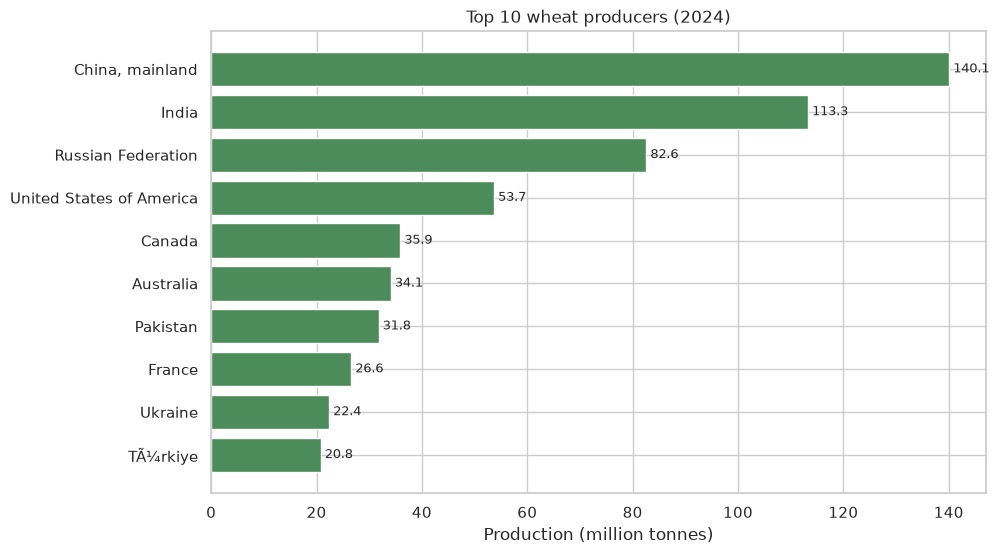

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(wheat_top["area"][::-1], wheat_top["production_Mt"][::-1], color="#4c8c5a")
ax.set_xlabel("Production (million tonnes)")
ax.set_title(f"Top 10 wheat producers ({year})")
for i, v in enumerate(wheat_top["production_Mt"][::-1]):
    ax.text(v, i, f" {v:,.1f}", va="center", fontsize=9)
save(fig, "top10_wheat_producers")
plt.show()

## 3. Top RICE producers (latest year)
Note the item name: FAOSTAT uses "Rice" (paddy) in QCL production.

In [5]:
rice_item = "Rice" if "Rice" in prod["item"].unique() else \
    [i for i in prod["item"].unique() if i.lower().startswith("rice")][0]
print("Using rice item:", rice_item)

rice_top = top_producers(prod, rice_item, year, 10)
print(f"Top 10 rice producers ({year}):")
print(rice_top[["area", "production_Mt"]].to_string(index=False))

Using rice item: Rice
Top 10 rice producers (2024):
           area  production_Mt
          India          217.9
China, mainland          207.5
     Bangladesh           60.6
      Indonesia           53.1
       Viet Nam           43.5
       Thailand           33.6
        Myanmar           27.6
    Philippines           19.1
       Pakistan           14.6
       Cambodia           14.2


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/top10_rice_producers.png


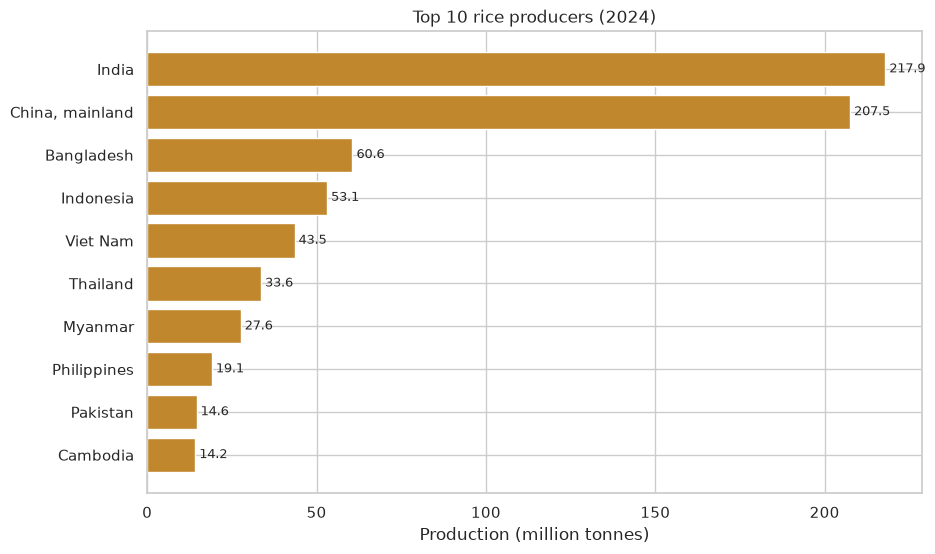

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rice_top["area"][::-1], rice_top["production_Mt"][::-1], color="#c0872d")
ax.set_xlabel("Production (million tonnes)")
ax.set_title(f"Top 10 rice producers ({year})")
for i, v in enumerate(rice_top["production_Mt"][::-1]):
    ax.text(v, i, f" {v:,.1f}", va="center", fontsize=9)
save(fig, "top10_rice_producers")
plt.show()

## 4. Quantity vs Value timeline — stacked panels (TRADE-style)
The production-side mirror of the deck's Indonesia import chart.

In [7]:
def quantity_value_panels(country, prod_item, title, start=2015, end=None,
                          q_color="#2e7d32", v_color="#c62828"):
    end = end or year
    q = (prod[(prod["area"] == country) & (prod["item"] == prod_item)
              & (prod["year"] >= start) & (prod["year"] <= end)]
         .groupby("year")["value"].sum())
    v = (val[(val["area"] == country) & (val["item"] == prod_item)
             & (val["year"] >= start) & (val["year"] <= end)]
         .groupby("year")["value"].sum())
    if q.empty:
        print(f"No production data for {country} / {prod_item}")
        return None

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ax1.plot(q.index, q.values / 1e6, "o-", color=q_color, linewidth=2, markersize=6)
    ax1.set_ylabel("Production quantity\n(million tonnes)")
    ax1.set_title(title)
    ax1.grid(alpha=0.3)

    if not v.empty:
        # QV current US$ is in 1000 US$ -> convert to million USD
        ax2.plot(v.index, v.values / 1e3, "s-", color=v_color, linewidth=2, markersize=6)
        ax2.set_ylabel("Production value\n(million USD)")
    else:
        ax2.text(0.5, 0.5, "No QV value data for this country/crop",
                 ha="center", va="center", transform=ax2.transAxes)
    ax2.set_xlabel("Year")
    ax2.grid(alpha=0.3)
    fig.tight_layout()
    return fig

### 4a. Indonesia — wheat production
Indonesia barely grows wheat (it's the world's top wheat *importer*), so this panel
is the striking contrast to the TRADE deck: near-zero domestic production is exactly
why Indonesia must import. If the series is flat/near-zero, that IS the finding.

In [8]:
fig = quantity_value_panels("Indonesia", "Wheat",
                            "Indonesia wheat PRODUCTION: quantity vs value (2015–2024)")
if fig:
    save(fig, "indonesia_wheat_production_qv")
    plt.show()

No production data for Indonesia / Wheat


### 4b. China — rice production
China is a top rice *producer* and a flexible rice importer. Expect quantity and
value both large and relatively smooth — the production backbone behind the deck's
"China + rice = flexible, discretionary imports" finding.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/china_rice_production_qv.png


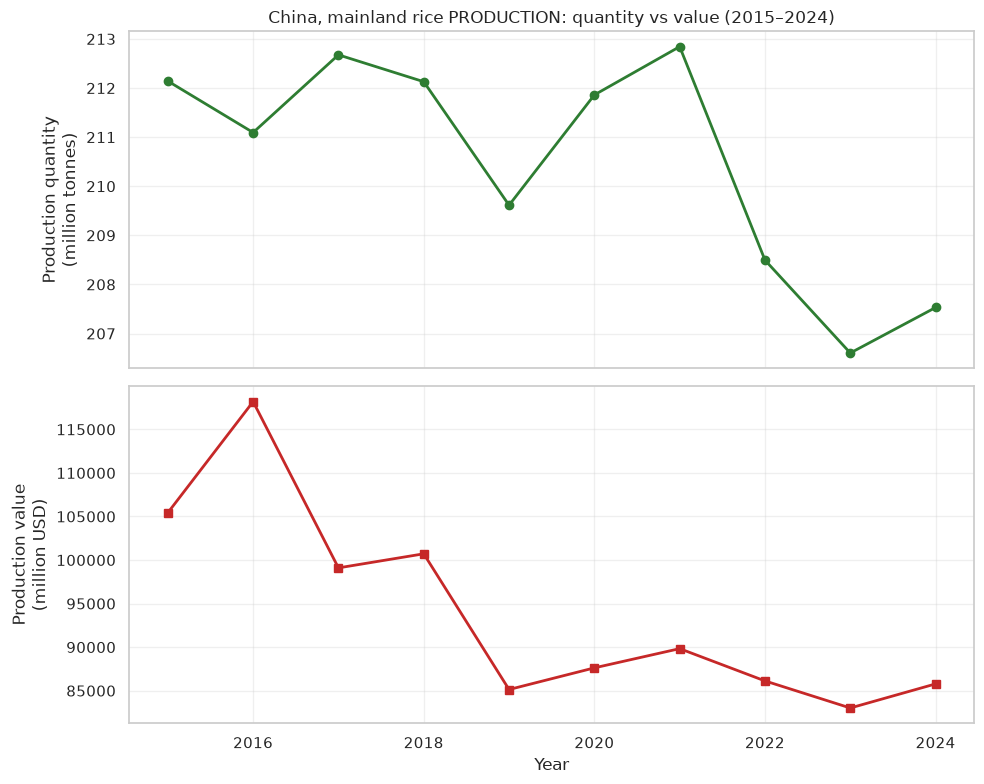

In [9]:
china = "China, mainland" if "China, mainland" in prod["area"].unique() else "China"
fig = quantity_value_panels(china, rice_item,
                            f"{china} rice PRODUCTION: quantity vs value (2015–2024)")
if fig:
    save(fig, "china_rice_production_qv")
    plt.show()

### 4c. Australia — wheat production
Indonesia has **no QCL wheat records at all** (not near-zero — literally absent),
so 4a can't show a production line. Australia is the real supply-side counterpart:
a top-5 global wheat exporter, so this is the production backbone feeding countries
like Indonesia that import wheat wholesale.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/australia_wheat_production_qv.png


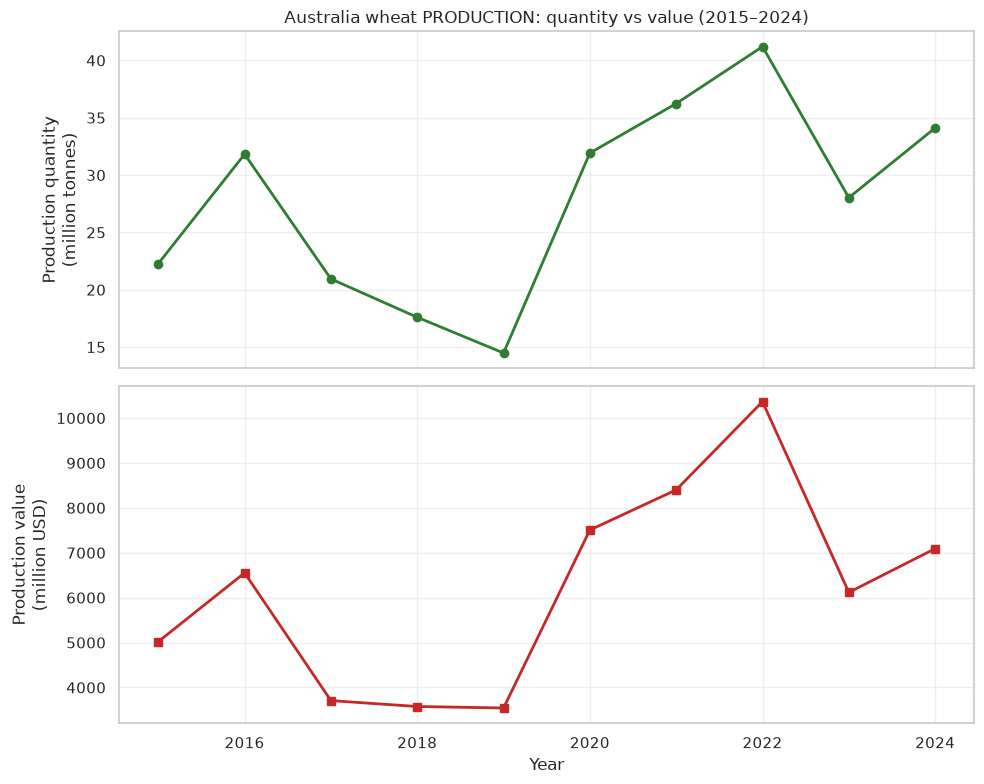

In [10]:
fig = quantity_value_panels("Australia", "Wheat",
                            "Australia wheat PRODUCTION: quantity vs value (2015–2024)")
if fig:
    save(fig, "australia_wheat_production_qv")
    plt.show()

### 4d. Viet Nam — rice production
FAOSTAT area name is "Viet Nam" (not "Vietnam"). Viet Nam is one of the world's
top rice exporters alongside China's rice-producer role in 4b — pairs with
the TRADE deck's rice-exporter side of the story.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/vietnam_rice_production_qv.png


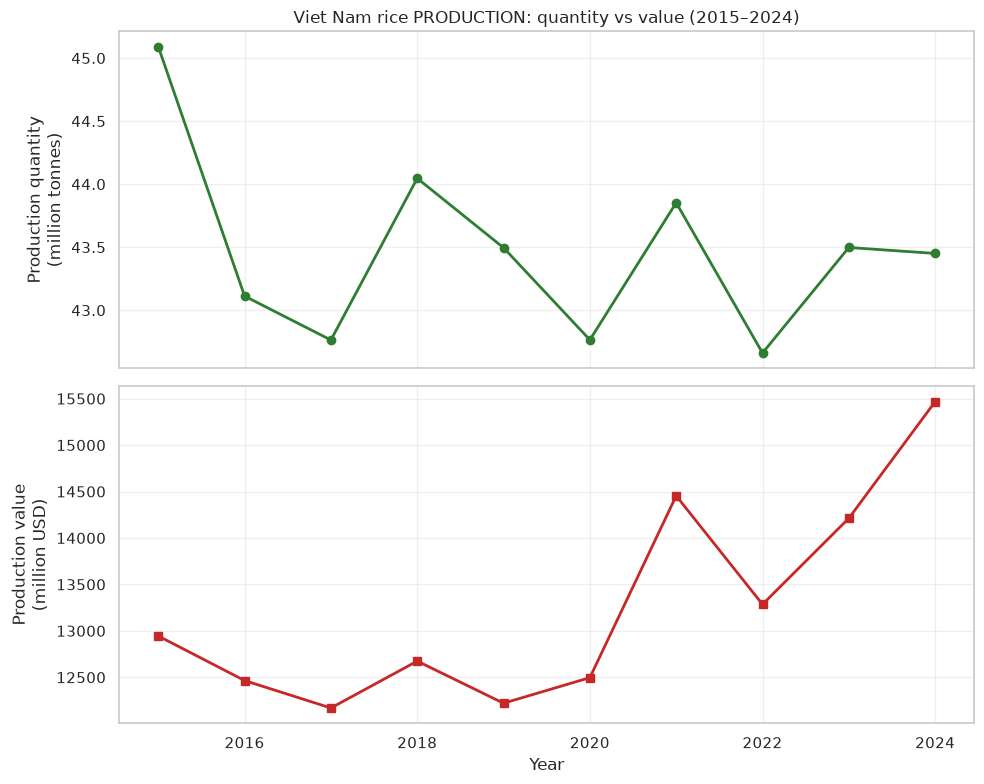

In [11]:
vietnam = "Viet Nam" if "Viet Nam" in prod["area"].unique() else "Vietnam"
fig = quantity_value_panels(vietnam, rice_item,
                            f"{vietnam} rice PRODUCTION: quantity vs value (2015–2024)")
if fig:
    save(fig, "vietnam_rice_production_qv")
    plt.show()

**Checkpoint / how this complements TRADE:**
- Top-producer bars show WHERE staples are grown — the supply base behind trade flows.
- Indonesia has **zero** QCL wheat records — not near-zero, literally no domestic
  production — the strongest possible production-side explanation for its import
  dependence (the deck's structural-vulnerability case).
- Australia wheat production is large and export-oriented — the supply side of
  countries like Indonesia that import wheat wholesale.
- China rice production large & stable → the production backing that lets it treat
  imports as discretionary (the deck's flexible-importer case).
- Viet Nam rice production is large and export-oriented, the mirror of China's
  discretionary-importer role — two different production profiles behind the
  same crop.
- Same countries/crops as the TRADE deck plus two producer-side complements
  (Australia wheat, Viet Nam rice) — production lens beside the trade lens.
